In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Dataset analysis

In [15]:
df = pd.read_csv('Student_Performance.csv')
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


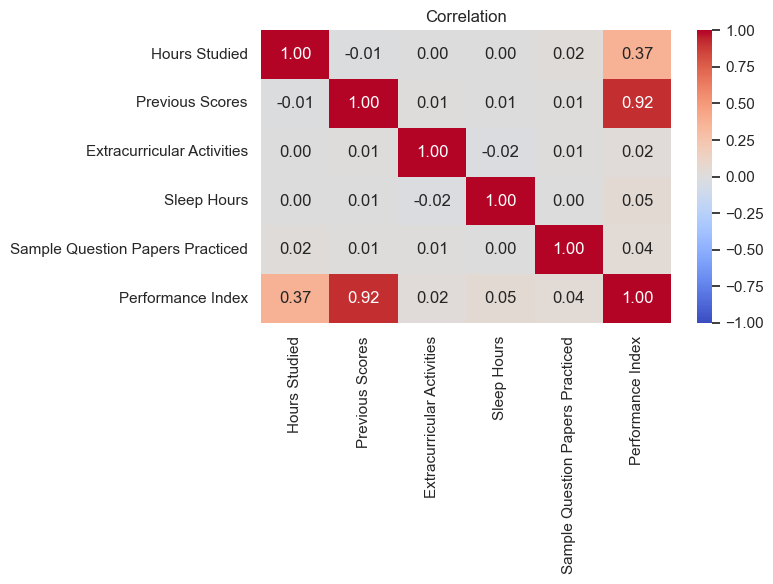

In [17]:
corr_matrix = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")

plt.title("Correlation")
plt.tight_layout()
plt.show()

In [18]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Previous Scores',
    y='Hours Studied',
    z='Performance Index',
    color='Performance Index',
    color_continuous_scale='Inferno',
    title='3D Plotting of dataset: Scores vs Hours Studied',
    opacity=0.7
)
fig.update_layout(
    font=dict(
        family="Arial, sans-serif",
        size=10,
        color="black"
    ),
    title=dict(
        font=dict(size=14)
    )
)
fig.update_traces(marker=dict(size=1))

fig.show()

In [19]:
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# Run Linear Regression on clean normalized data

In [20]:
from OptimizationMethodsComparison.LinearRegression import LinearRegression
from OptimizationMethodsComparison.FunctionsForAnalysis import plot_optimization_results, plot_summary_bars, run_grid_search_bgd, run_grid_search_adam

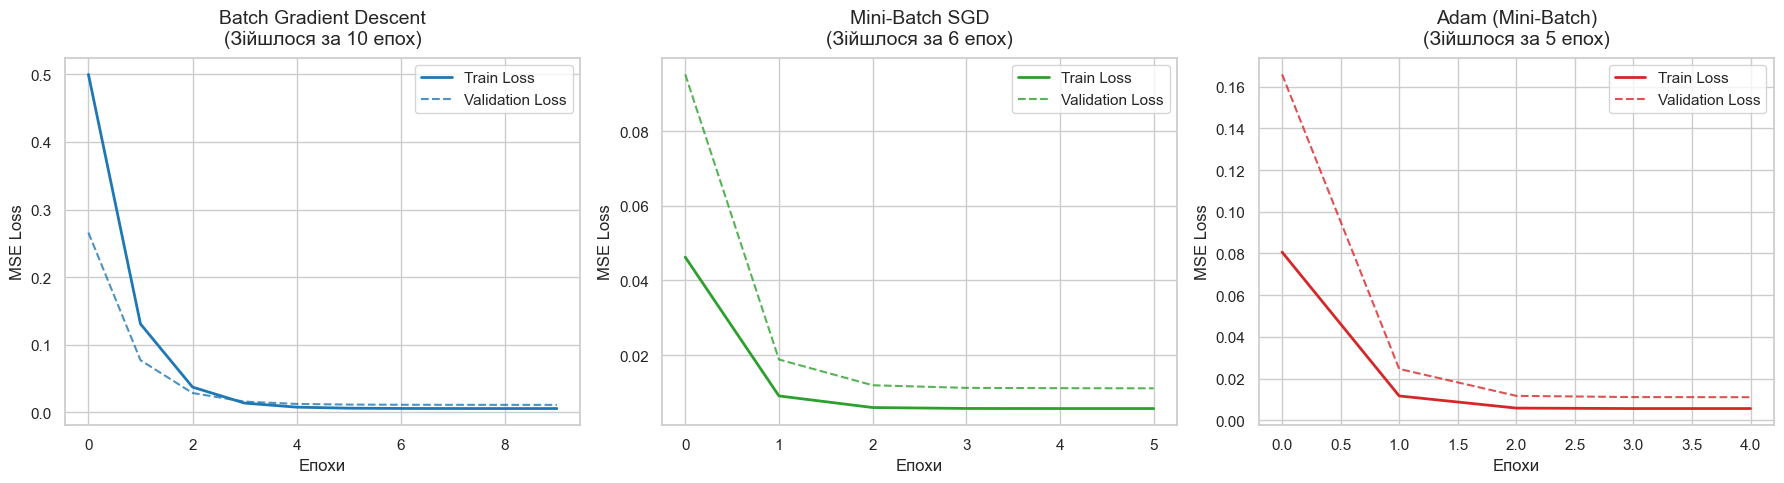

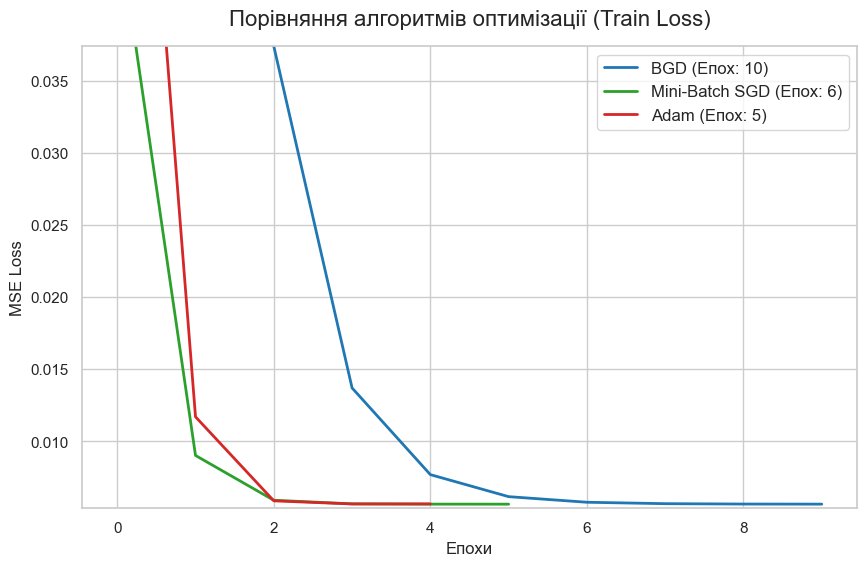

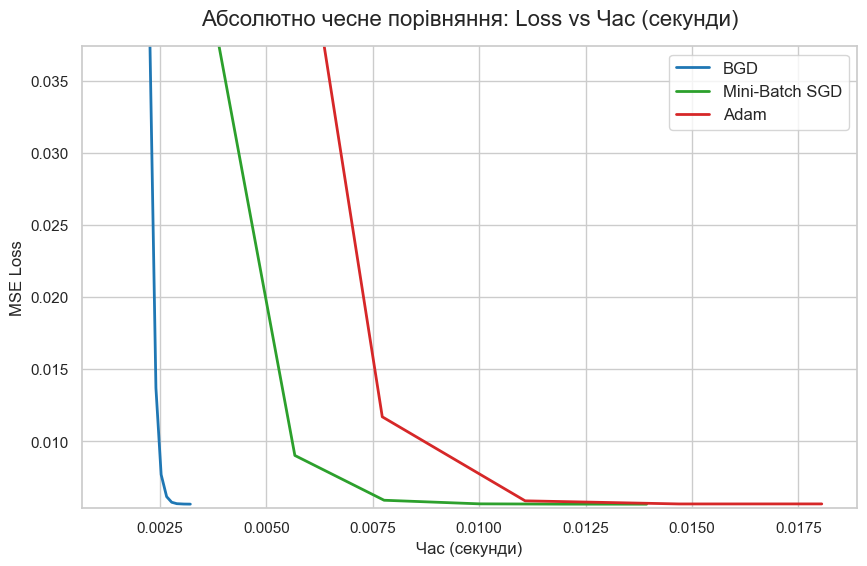

In [34]:
batch_size = 64
model_bgd = LinearRegression(X_train, y_train, normalize=True)
model_mbgd = LinearRegression(X_train, y_train, normalize=True)
model_adam = LinearRegression(X_train, y_train, normalize=True)

res_bgd = model_bgd.fit_batch_grad(alpha=0.5, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test)
res_mbgd = model_mbgd.fit_mini_batch_grad(alpha=0.01, batch_size=batch_size, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test)
res_adam = model_adam.fit_adam_batch(alpha=0.005, batch_size=batch_size, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test)

plot_optimization_results(res_bgd, res_mbgd, res_adam)

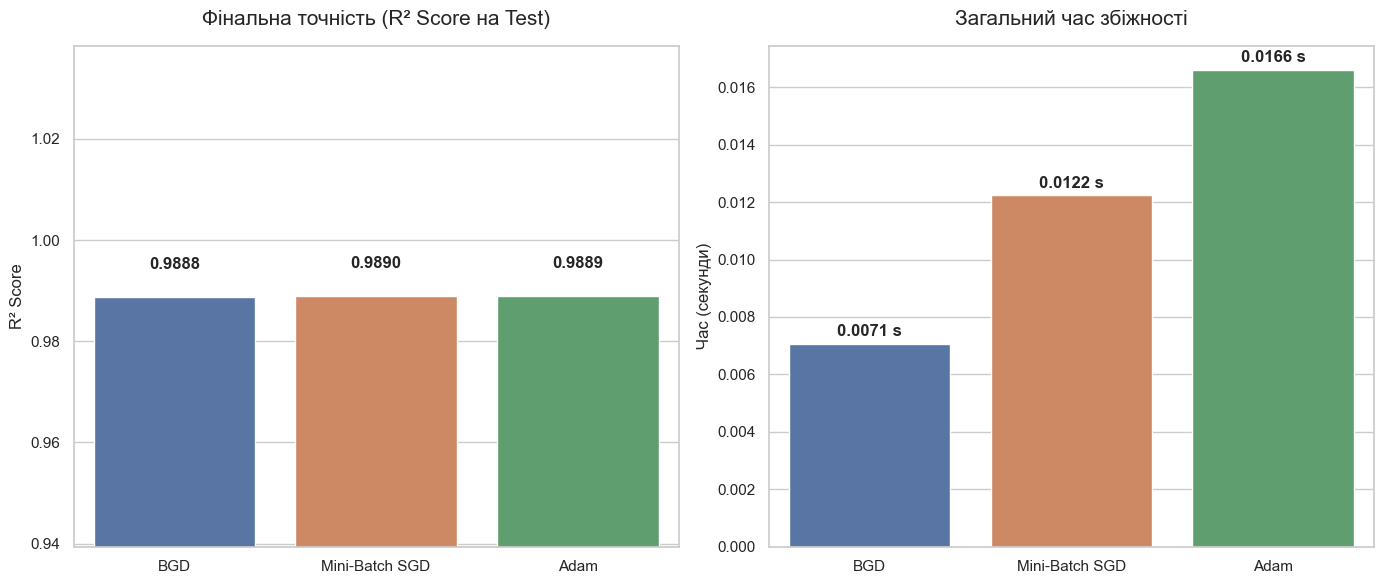

In [35]:
batch_size = 64
model_bgd = LinearRegression(X_train, y_train, normalize=True)
model_mbgd = LinearRegression(X_train, y_train, normalize=True)
model_adam = LinearRegression(X_train, y_train, normalize=True)

res_bgd = model_bgd.fit_batch_grad(alpha=0.1, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test)
res_mbgd = model_mbgd.fit_mini_batch_grad(alpha=0.01, batch_size=batch_size, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test)
res_adam = model_adam.fit_adam_batch(alpha=0.005, batch_size=batch_size, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test)

plot_summary_bars(
    model_bgd=model_bgd,
    model_mbgd=model_mbgd,
    model_adam=model_adam,
    res_bgd=res_bgd,
    res_mbgd=res_mbgd,
    res_adam=res_adam,
    X_test=X_test,
    y_test=y_test
)

# Run Linear Regression without normalization
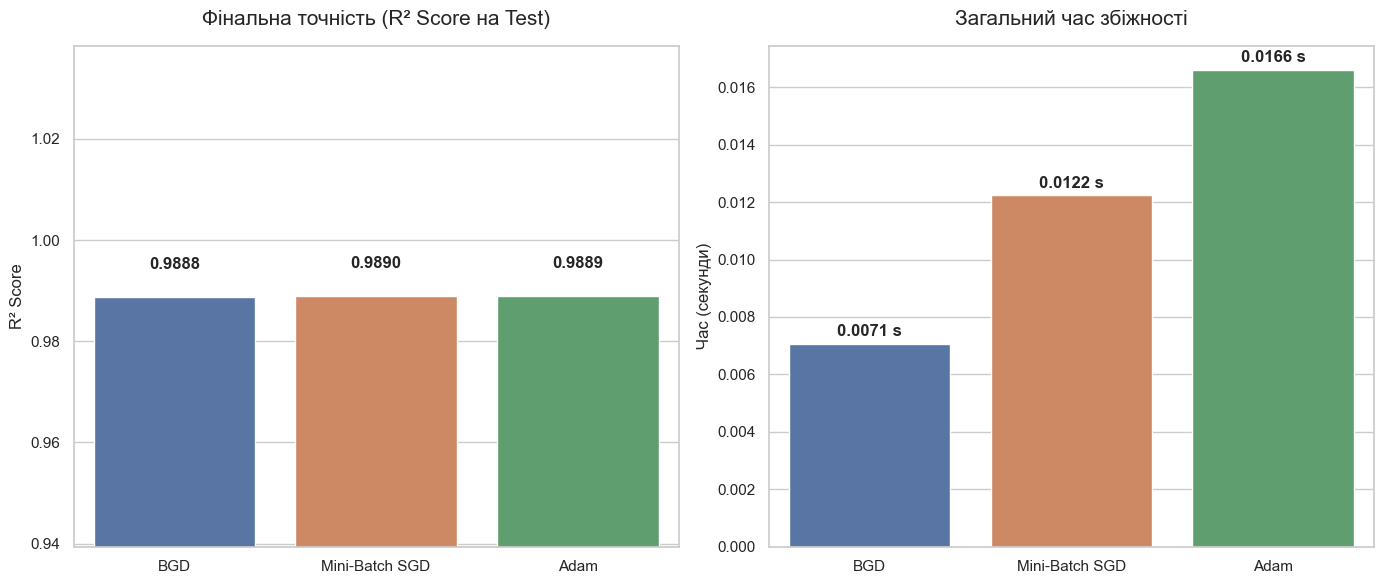

normalize=False, lr had to be changed to smaller (0.0001) for BGD and MiniBGD. max_epoch hed to changed to 10000 


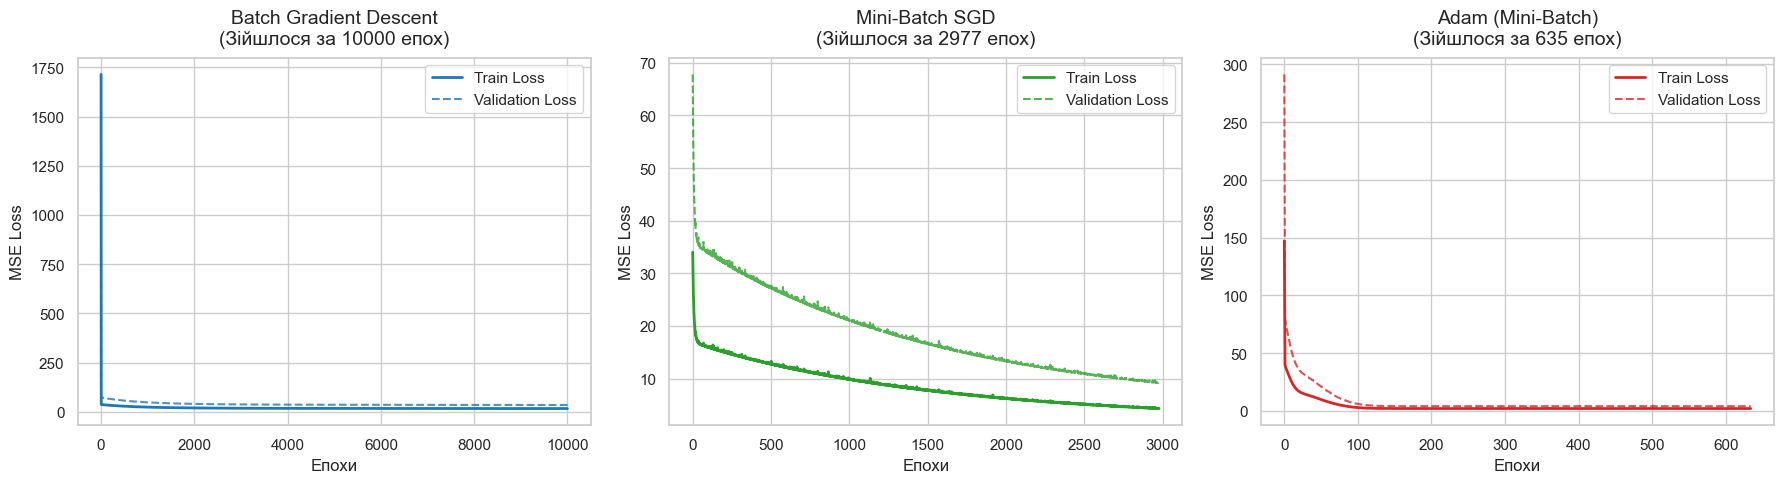

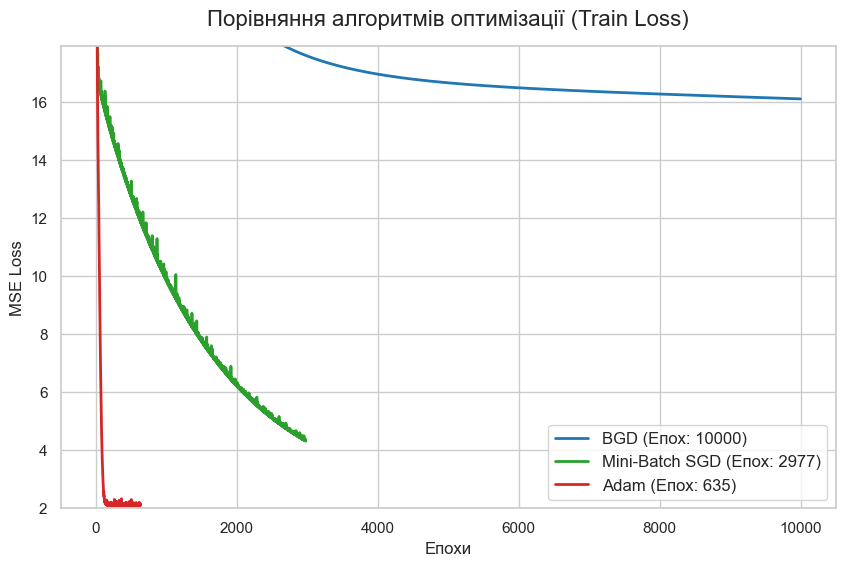

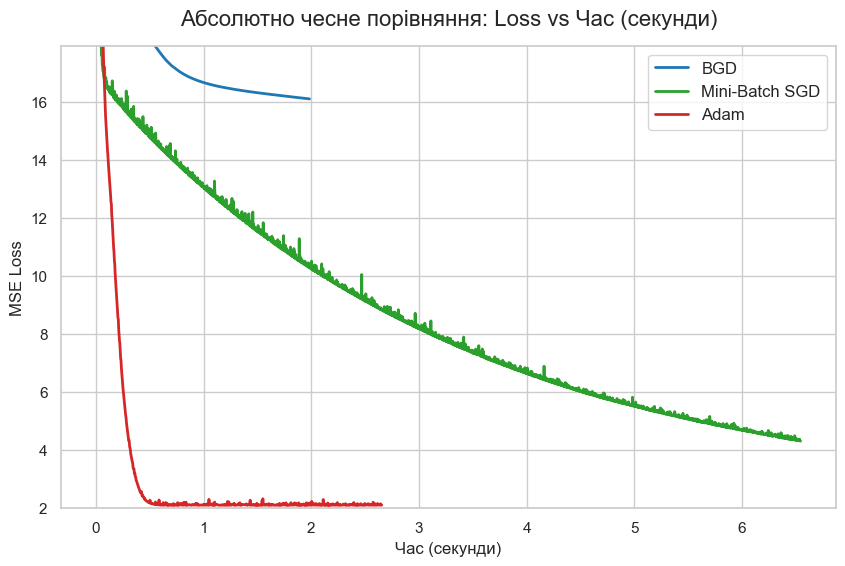

In [43]:
print("normalize=False, lr had to be changed to smaller (0.0001) for BGD and MiniBGD. max_epoch hed to changed to 10000 ")
batch_size = 64
model_bgd = LinearRegression(X_train, y_train, normalize=False)
model_mbgd = LinearRegression(X_train, y_train, normalize=False)
model_adam = LinearRegression(X_train, y_train, normalize=False)

res_bgd = model_bgd.fit_batch_grad(alpha=0.0001, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test, max_epochs=10000)
res_mbgd = model_mbgd.fit_mini_batch_grad(alpha=0.0001, batch_size=batch_size, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test, max_epochs=10000)
res_adam = model_adam.fit_adam_batch(alpha=0.005, batch_size=batch_size, track_history=True, verbose=False, X_validation=X_test, y_validation=y_test, max_epochs=10000)

plot_optimization_results(res_bgd, res_mbgd, res_adam)

normalize=False, lr had to be changed to smaller (0.0001) for BGD and MiniBGD. max_epoch hed to changed to 10000 


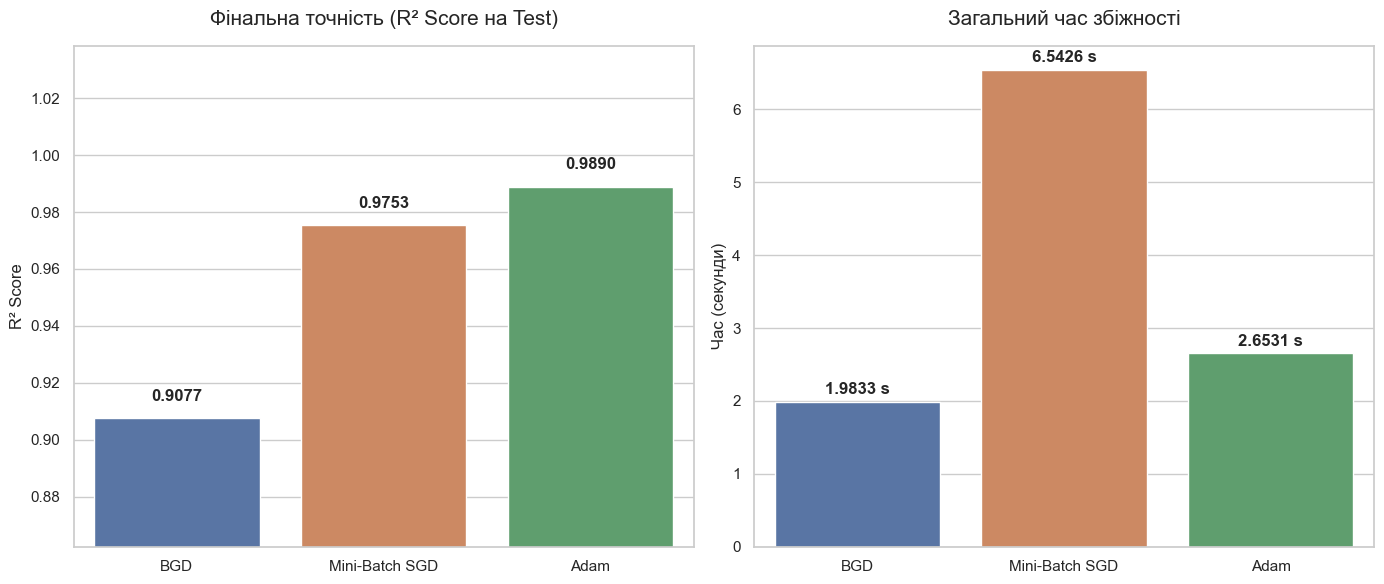

In [44]:
print("normalize=False, lr had to be changed to smaller (0.0001) for BGD and MiniBGD. max_epoch hed to changed to 10000 ")
plot_summary_bars(
    model_bgd=model_bgd,
    model_mbgd=model_mbgd,
    model_adam=model_adam,
    res_bgd=res_bgd,
    res_mbgd=res_mbgd,
    res_adam=res_adam,
    X_test=X_test,
    y_test=y_test
)

# Run Linear Regression on Artificially Corrupted Dataset

In [46]:
X_tr = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else X_train
X_te = X_test.to_numpy() if hasattr(X_test, 'to_numpy') else X_test
y_tr = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train
y_te = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else y_test

m_small = 50
X_train_small = X_tr[:m_small]
y_train_small = y_tr[:m_small]

n_noise = 80
noise_tr = np.random.randn(m_small, n_noise)
noise_te = np.random.randn(X_te.shape[0], n_noise)

X_train_corrupted = np.hstack((X_train_small, noise_tr))
X_test_corrupted = np.hstack((X_te, noise_te))

print(f"Тренувальні дані: {X_train_corrupted.shape[0]} рядків, {X_train_corrupted.shape[1]} фіч з яких {n_noise} фіч-сміття")

Тренувальні дані: 50 рядків, 85 фіч з яких 80 фіч-сміття


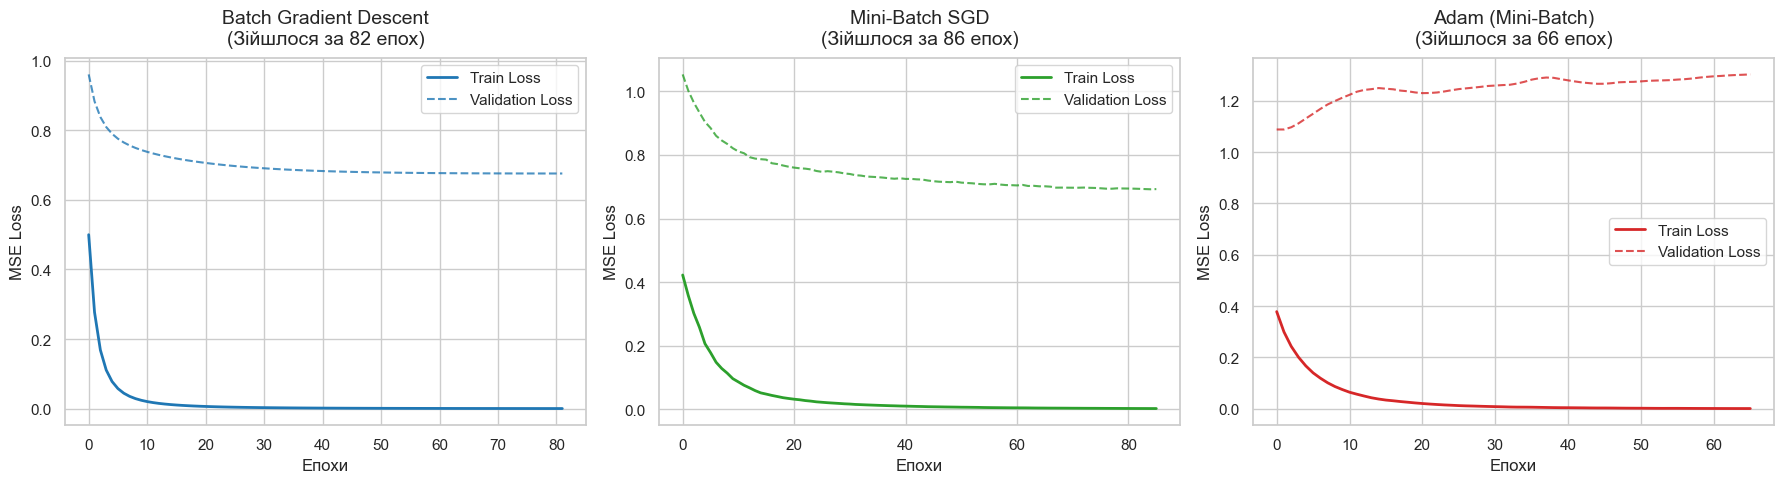

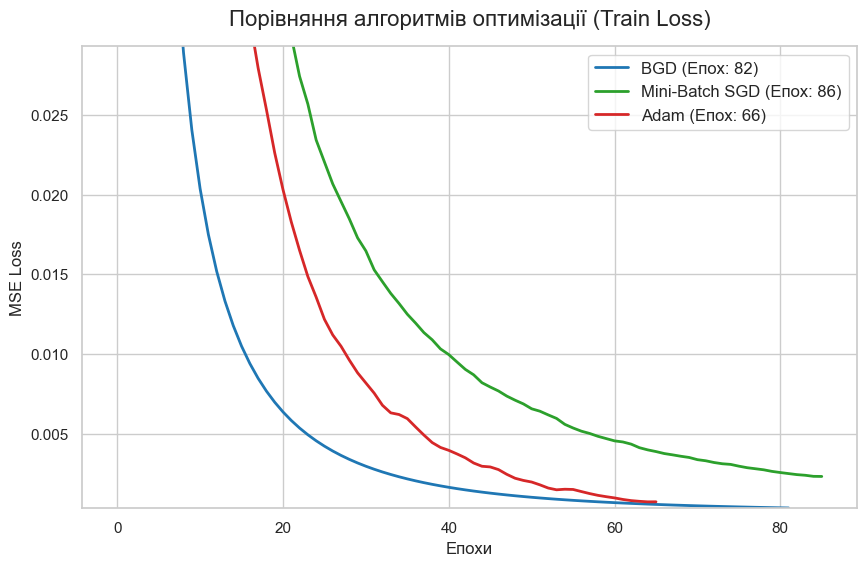

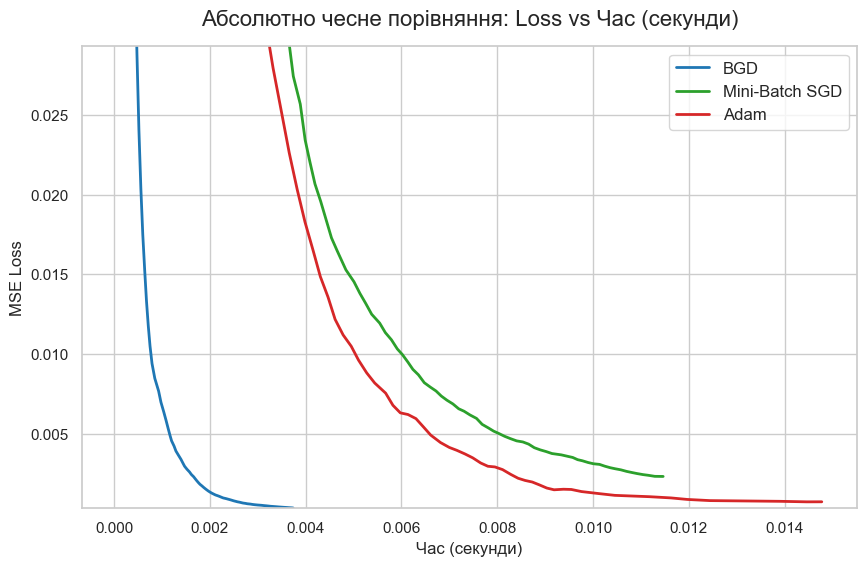

In [56]:
batch_size = 16
model_bgd = LinearRegression(X_train_corrupted, y_train_small, normalize=True)
model_mbgd = LinearRegression(X_train_corrupted, y_train_small, normalize=True)
model_adam = LinearRegression(X_train_corrupted, y_train_small, normalize=True)

res_bgd = model_bgd.fit_batch_grad(alpha=0.1, track_history=True, verbose=False, X_validation=X_test_corrupted, y_validation=y_test, max_epochs=1000)
res_mbgd = model_mbgd.fit_mini_batch_grad(alpha=0.01, batch_size=batch_size, track_history=True, verbose=False, X_validation=X_test_corrupted, y_validation=y_test, max_epochs=1000)
res_adam = model_adam.fit_adam_batch(alpha=0.005, batch_size=batch_size, track_history=True, verbose=False, X_validation=X_test_corrupted, y_validation=y_test, max_epochs=1000)

plot_optimization_results(res_bgd, res_mbgd, res_adam)

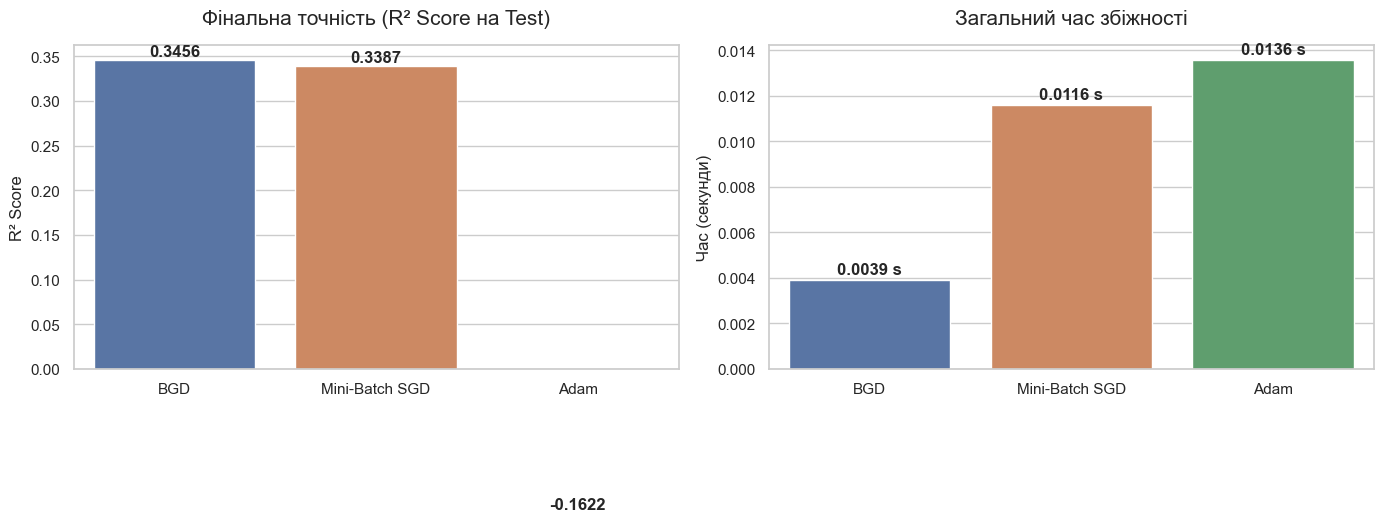

In [48]:
plot_summary_bars(
    model_bgd=model_bgd,
    model_mbgd=model_mbgd,
    model_adam=model_adam,
    res_bgd=res_bgd,
    res_mbgd=res_mbgd,
    res_adam=res_adam,
    X_test=X_test_corrupted,
    y_test=y_test
)

In [53]:
best_model, best_params, results_df = run_grid_search_bgd(X_train_corrupted, y_train_small, X_test_corrupted, y_test, weights_on = False)

print("🏆 Найкращі гіперпараметри BGD (погані дані):")
print(best_params)
print(f"🏆 Найкращий R2 Score: {best_model.evaluate_r(X_test_corrupted, y_test):.5f}")

print("\nТаблиця результатів (Топ-10):")
print(results_df.head(10).to_string())

Починаємо Grid Search для BGD...


D:\MyProjects\MachineLearningFromScrach\.venv\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning:

overflow encountered in reduce

D:\MyProjects\MachineLearningFromScrach\OptimizationMethodsComparison\LinearRegression.py:83: RuntimeWarning:

invalid value encountered in scalar subtract

D:\MyProjects\MachineLearningFromScrach\OptimizationMethodsComparison\LinearRegression.py:51: RuntimeWarning:

overflow encountered in square

D:\MyProjects\MachineLearningFromScrach\OptimizationMethodsComparison\LinearRegression.py:288: RuntimeWarning:

overflow encountered in square

D:\MyProjects\MachineLearningFromScrach\OptimizationMethodsComparison\LinearRegression.py:296: RuntimeWarning:

overflow encountered in square

D:\MyProjects\MachineLearningFromScrach\.venv\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning:

overflow encountered in reduce

D:\MyProjects\MachineLearningFromScrach\OptimizationMethodsComparison\LinearRegression.py:53: RuntimeWarning:

overflow encounte

Grid Search завершено!

🏆 Найкращі гіперпараметри BGD (погані дані):
{'alpha': 0.1, 'penalty': 'l1', 'lambda': 1.0}
🏆 Найкращий R2 Score: 0.97661

Таблиця результатів (Топ-10):
   Alpha Penalty Lambda  Epochs   Test R2  Test MSE Weights (Theta)
0  0.100      l1    1.0     155  0.976615  0.024155      Turned off
1  0.010      l1    1.0     745  0.857624  0.147060      Turned off
2  0.050      l1    1.0     139  0.835781  0.169621      Turned off
3  0.001      l1    1.0    1686  0.458785  0.559019      Turned off
4  0.100      l1    0.1      97  0.451671  0.566367      Turned off
5  0.050      l1    0.1     146  0.423161  0.595815      Turned off
6  0.010      l1    0.1     393  0.377182  0.643307      Turned off
7  0.100      l1   0.01      82  0.354447  0.666790      Turned off
8  0.050      l1   0.01     132  0.351979  0.669338      Turned off
9  0.100      l1  0.001      82  0.346505  0.674993      Turned off


In [54]:
best_model, best_params, results_df = run_grid_search_adam(X_train_corrupted, y_train_small, X_test_corrupted, y_test, batch_size=16, weights_on = False)

print("🏆 Найкращі гіперпараметри Adam (погані дані):")
print(best_params)
print(f"🏆 Найкращий R2 Score: {best_model.evaluate_r(X_test_corrupted, y_test):.5f}")

print("\nТаблиця результатів (Топ-10):")
print(results_df.head(10).to_string())

Починаємо Grid Search для Adam ...
Grid Search завершено!

🏆 Найкращі гіперпараметри Adam (погані дані):
{'alpha': 0.1, 'penalty': 'l1', 'lambda': 1.0}
🏆 Найкращий R2 Score: 0.97634

Таблиця результатів (Топ-10):
   Alpha Penalty Lambda  Epochs   Test R2  Test MSE Weights (Theta)
0  0.100      l1    1.0     828  0.976339  0.024439      Turned off
1  0.010      l1    1.0     731  0.975026  0.025796      Turned off
2  0.500      l1    1.0     543  0.974659  0.026175      Turned off
3  0.100      l1    0.1     629  0.495003  0.521609      Turned off
4  0.001      l1    1.0     284  0.394110  0.625822      Turned off
5  0.100      l2    1.0     459  0.339588  0.682138      Turned off
6  0.500      l2    1.0     243  0.210623  0.815345      Turned off
7  0.001      l1    0.1     313 -0.107254  1.143678      Turned off
8  0.100      l1   0.01     355 -0.107625  1.144062      Turned off
9  0.001      l2    1.0     254 -0.136349  1.173731      Turned off
